In [1]:
import pandas as pd
import numpy as np
import glob 
import duckdb
import os
os.chdir("..")
import plotting_helpers
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from trebl_tools import plotting

# Calculating activity per BC combo

In [2]:
step1_map = pd.read_csv("../../output/GCN4_pipeline/step1.csv")
step1_map = step1_map[["AD", "AD_BC", "RPTR_BC"]].drop_duplicates()
step1_map

,AD,AD_BC,RPTR_BC
0,CCATTGTTCTCTCAATCTACTGGTAATATTCCACAAACTCCAAATA...,CGTCATAACGT,TGTCTTACTTATGC
1,GATGAATCTCCAACTTCTATGCCAGAAGATGTTGTTGTTGCTGATC...,GAGCCGTGGAA,GGTGACAGCAATGC
2,TCTTCTCCAGTTGTTAAACCAGTTTCTTCTCCAGCTAGATCTCCAA...,ACTCCGAGAAA,TTATAAAAGATTGC
3,CAACCATCTCATCAAGACTTTGTCTTGTTTGAAAGATCTCCATCTG...,ACGCATGCTCA,ACGCTGACCCGTAC
4,ACTCCAAATATGGTTATGCAAGATATGGATTTGTTTGATGACTTTA...,CTAATTTTATC,GATCGACAACGCCC
...,...,...,...
172971,GCTCCAACTCATCAAGCTATGATTGCTGATATTATTGTTAAGAATG...,TACGAAATCTG,GCTATGAACCGAAG
172972,GACTTTAATACTGCTGTTCCAACTATTTCTCCACAAGAATTGTTGA...,GATCAGATTGA,CCTTGGTAACTATC
172973,ACTTCTTTGAGATCTTCTCCATCTTCTAGAGTTCATTTGCAAAGAT...,TGGGAATGCTA,AATTGAGACTAATG
172974,AATTCTACTGCATTTACTAATTTGACTTCTCCATCTACTTATAATG...,ATTTCTTAAGA,TCTAAGCCCGAATG


In [3]:
AD_results = pd.read_csv("../../output/GCN4_pipeline/AD_trebl_experiment_pool_A_results.csv")
AD_results["rep"] = AD_results["sample"].astype(str).str.extract(r'AD_(\d+)').astype(int)
AD_results["time"] = AD_results["sample"].astype(str).str.extract(r'AD_\d+_(\d+)').astype(int)
AD_results

,AD,AD_BC,count,sample,rep,time
0,GATTCTTTGTTTGAATCTCAAGATTTGTTTGCTTCTCCAGTTAAAC...,CTCCACTGCCC,660,Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCC...,3,0
1,TCTCATACTACTACTGTTACTCAAACTGTTGTTTCTTCTAAACCAG...,CGTCCGATAAG,417,Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCC...,3,0
2,GGTAATGTTCCACAAACTCCAAAATGGCTATGCAAGGTAAATTTCA...,CCAATCCTACT,411,Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCC...,3,0
3,CAACCAAATCCATATTTGAGAGCTTTGGCTTTGTCTCCAACTCCAG...,TAGAATAAGAC,388,Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCC...,3,0
4,GATCAATCTCCAGGTATCTTTGCTGGTGATGCTGTTATGGCTTCTG...,GTTTCTCGCTA,380,Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCC...,3,0
...,...,...,...,...,...,...
15890,AAGATGAAACAAGGTATTTCTTCTTCTCCATCTCCACCATCTTCTT...,CTGCTACGCGA,11,Staller_AD_3_5_2_MVS_0074_I1_MVS_0074_I2_GTATT...,3,5
15891,TTTCCAGAAATCTTGACTTCTTCTCCAGCTTCTAGTTTAGATTCTC...,GAATGTGTAAC,11,Staller_AD_3_5_2_MVS_0074_I1_MVS_0074_I2_GTATT...,3,5
15892,TTGGCTGCTAGGAAATCTAGAGAAAGGAAAGCTCAGAAATTGGAAG...,ATGAGGTTGAG,11,Staller_AD_3_5_2_MVS_0074_I1_MVS_0074_I2_GTATT...,3,5
15893,AGGAAGAATATGATTTCTGTTGATATTGGTATTGGTAGATTTGTTA...,ATATCTTATCA,11,Staller_AD_3_5_2_MVS_0074_I1_MVS_0074_I2_GTATT...,3,5


In [4]:
RT_results = pd.read_csv("../../output/GCN4_pipeline/RT_trebl_experiment_pool_A_results.csv")
RT_results["rep"] = RT_results["sample"].astype(str).str.extract(r'RPTR_(\d+)').astype(int)
RT_results["time"] = RT_results["sample"].astype(str).str.extract(r'RPTR_\d+_(\d+)').astype(int)
RT_results

,RPTR_BC,count,sample,rep,time
0,CCTGGGATATGAGT,1162,Staller_RPTR_3_0_2_MVS_0078_I1_MVS_0078_I2_AAG...,3,0
1,TGGGCCGGAATTGC,1054,Staller_RPTR_3_0_2_MVS_0078_I1_MVS_0078_I2_AAG...,3,0
2,GCTTCTCCGCACAT,1032,Staller_RPTR_3_0_2_MVS_0078_I1_MVS_0078_I2_AAG...,3,0
3,GTCCAGTTTAGTGA,980,Staller_RPTR_3_0_2_MVS_0078_I1_MVS_0078_I2_AAG...,3,0
4,TTATTTAGAAGTTT,878,Staller_RPTR_3_0_2_MVS_0078_I1_MVS_0078_I2_AAG...,3,0
...,...,...,...,...,...
14013,CGACCGGATTCATC,11,Staller_RPTR_3_5_2_MVS_0079_I1_MVS_0079_I2_TCT...,3,5
14014,TGGCCTCTCCCCCG,11,Staller_RPTR_3_5_2_MVS_0079_I1_MVS_0079_I2_TCT...,3,5
14015,AAAGACGAAACCGC,11,Staller_RPTR_3_5_2_MVS_0079_I1_MVS_0079_I2_TCT...,3,5
14016,CCGACATTGCCCAC,11,Staller_RPTR_3_5_2_MVS_0079_I1_MVS_0079_I2_TCT...,3,5


In [5]:
step1_map_AD = pd.merge(step1_map, AD_results).drop(columns = 'sample')
step1_map_AD

,AD,AD_BC,RPTR_BC,count,rep,time
0,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,50,3,0
1,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,79,3,10
2,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,87,3,240
3,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,73,3,240
4,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,81,3,5
...,...,...,...,...,...,...
10470,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,148,3,240
10471,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,134,3,240
10472,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,136,3,5
10473,CAAGTTCCAAGAGTTGCTAGATTGGCTTCTCAATCTACTGGATTTC...,AAATTTTCTAC,TGATGGTGTGATCT,11,3,10


In [6]:
step1_map_RT = pd.merge(step1_map, RT_results).drop(columns = 'sample')
step1_map_RT

,AD,AD_BC,RPTR_BC,count,rep,time
0,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,59,3,0
1,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,281,3,10
2,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,287,3,240
3,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,267,3,240
4,CAGAATCAATATGCTCAATCTATTAATCATAGAAGAATTATGTCTA...,AAAGTTACCGT,TACTAAGAAATAGA,144,3,5
...,...,...,...,...,...,...
9418,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,112,3,0
9419,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,68,3,10
9420,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,66,3,240
9421,GTTGCTGAATCTATTGTTGAACAATTGGAAACTGGTGAACAAGCTG...,TCCTATCATAT,AACGACGCACTGTA,58,3,240


In [7]:
AD_RT_merged = pd.merge(step1_map_AD, step1_map_RT, how = 'outer', on = ["AD", "AD_BC", "RPTR_BC", "rep", "time"], suffixes = ("_AD", "_RT"))
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT
0,AAACAAGGTAATAAGATGTTCTCTGAATTGGATTTGTTGGACTTTG...,ACGAGCACCTA,CTCGGGGCCCTCAA,27.0,3,0,NaN
1,AAACAAGGTAATAAGATGTTCTCTGAATTGGATTTGTTGGACTTTG...,ACGAGCACCTA,CTCGGGGCCCTCAA,50.0,3,5,NaN
2,AAACAAGGTAATAAGATGTTCTCTGAATTGGATTTGTTGGACTTTG...,ACGAGCACCTA,CTCGGGGCCCTCAA,58.0,3,10,NaN
3,AAACAAGGTAATAAGATGTTCTCTGAATTGGATTTGTTGGACTTTG...,ACGAGCACCTA,CTCGGGGCCCTCAA,78.0,3,240,NaN
4,AAACAAGGTAATAAGATGTTCTCTGAATTGGATTTGTTGGACTTTG...,ACGAGCACCTA,CTCGGGGCCCTCAA,60.0,3,240,NaN
...,...,...,...,...,...,...,...
15221,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,284.0,3,10,170.0
15222,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0
15223,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0
15224,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,307.0,3,240,126.0


In [8]:
sum(AD_RT_merged["count_AD"].isna())

1707

In [9]:
sum(AD_RT_merged["count_RT"].isna())

2737

In [10]:
# For now, ignore the nulls
AD_RT_merged = AD_RT_merged.dropna()
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT
5,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,25.0,3,0,182.0
6,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,37.0,3,5,154.0
7,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,52.0,3,10,285.0
8,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,45.0,3,240,248.0
9,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,45.0,3,240,236.0
...,...,...,...,...,...,...,...
15221,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,284.0,3,10,170.0
15222,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0
15223,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0
15224,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,307.0,3,240,126.0


In [11]:
# AD_RT_merged.drop(columns = "RPTR_BC").groupby(["AD", "AD_BC", "rep", "time"]).sum()

In [12]:
AD_RT_merged["activity"] = AD_RT_merged["count_RT"] / AD_RT_merged["count_AD"]
AD_RT_merged

,AD,AD_BC,RPTR_BC,count_AD,rep,time,count_RT,activity
5,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,25.0,3,0,182.0,7.280000
6,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,37.0,3,5,154.0,4.162162
7,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,52.0,3,10,285.0,5.480769
8,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,45.0,3,240,248.0,5.511111
9,AAACAATTGCAAACTAATTCTAATATGTCTGATGATACATTTGCTG...,TATCCCCCCGG,AGCCGTGGGACGCT,45.0,3,240,236.0,5.244444
...,...,...,...,...,...,...,...,...
15221,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,284.0,3,10,170.0,0.598592
15222,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0,0.313433
15223,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,402.0,3,240,126.0,0.313433
15224,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,307.0,3,240,126.0,0.410423


In [14]:
AD_RT_merged.to_csv("../../output/GCN4_pipeline/trebl_experiment_pool_A_results_per_barcode.csv")

# Saving barcode loss

In [2]:
db_path = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/duckdb/GCN4_pipeline.db"
con = duckdb.connect(db_path)

In [4]:
AD_prefixes_df, RT_prefixes_df = plotting_helpers.get_prefix_df("trebl_experiment_pool_A_", con)

trebl_experiment_pool_A_Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCCTGATG_AGGTCGTGTC_S20_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_0_2_MVS_0073_I1_MVS_0073_I2_GCTCCTGATG_AGGTCGTGTC_S20_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_10_1_MVS_0075_I1_MVS_0075_I2_CTGTCCACAC_CACTGTATAG_S22_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_10_1_MVS_0075_I1_MVS_0075_I2_CTGTCCACAC_CACTGTATAG_S22_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_240_1_50p_MVS_0071_I1_MVS_0071_I2_TTCAATACGC_CTTGCACGAG_S18_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_240_1_50p_MVS_0071_I1_MVS_0071_I2_TTCAATACGC_CTTGCACGAG_S18_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_240_1_67p_MVS_0072_I1_MVS_0072_I2_GTCGACTAAC_AAGACCTGAG_S19_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_240_1_67p_MVS_0072_I1_MVS_0072_I2_GTCGACTAAC_AAGACCTGAG_S19_AD_AD_BC_loss_summary
trebl_experiment_pool_A_Staller_AD_3_5_2_MVS_0074_I1_MVS_0074_I2_GTATT

In [5]:
AD_loss_table_dict = plotting_helpers.build_loss_table_dict(AD_prefixes_df["id"], con, step1_table = "../../output/GCN4_pipeline/step1.csv")
RT_loss_table_dict = plotting_helpers.build_loss_table_dict(RT_prefixes_df["id"], con, step1_table = "../../output/GCN4_pipeline/step1.csv")

registering temp step1


100%|██████████| 5/5 [00:00<00:00,  9.47it/s]


registering temp step1


100%|██████████| 5/5 [00:00<00:00, 20.45it/s]


In [8]:
AD_prefixes_df["rep"] = AD_prefixes_df["rep"].astype(int)
AD_prefixes_df["time"] = AD_prefixes_df["time"].astype(int)
AD_prefixes_df = AD_prefixes_df.sort_values(by = ["rep", "time"])
AD_prefixes_df

,id,rep,time
0,trebl_experiment_pool_A_Staller_AD_3_0_2_MVS_0...,3,0
4,trebl_experiment_pool_A_Staller_AD_3_5_2_MVS_0...,3,5
1,trebl_experiment_pool_A_Staller_AD_3_10_1_MVS_...,3,10
2,trebl_experiment_pool_A_Staller_AD_3_240_1_50p...,3,240
3,trebl_experiment_pool_A_Staller_AD_3_240_1_67p...,3,240


In [9]:
RT_prefixes_df["rep"] = RT_prefixes_df["rep"].astype(int)
RT_prefixes_df["time"] = RT_prefixes_df["time"].astype(int)
RT_prefixes_df = RT_prefixes_df.sort_values(by = ["rep", "time"])
RT_prefixes_df

,id,rep,time
0,trebl_experiment_pool_A_Staller_RPTR_3_0_2_MVS...,3,0
4,trebl_experiment_pool_A_Staller_RPTR_3_5_2_MVS...,3,5
1,trebl_experiment_pool_A_Staller_RPTR_3_10_1_MV...,3,10
2,trebl_experiment_pool_A_Staller_RPTR_3_240_1_5...,3,240
3,trebl_experiment_pool_A_Staller_RPTR_3_240_1_6...,3,240


100%|██████████| 5/5 [00:02<00:00,  2.46it/s]


Text(0.5, 1.1, 'Yeast Pool A, AD Trebl Experiment')

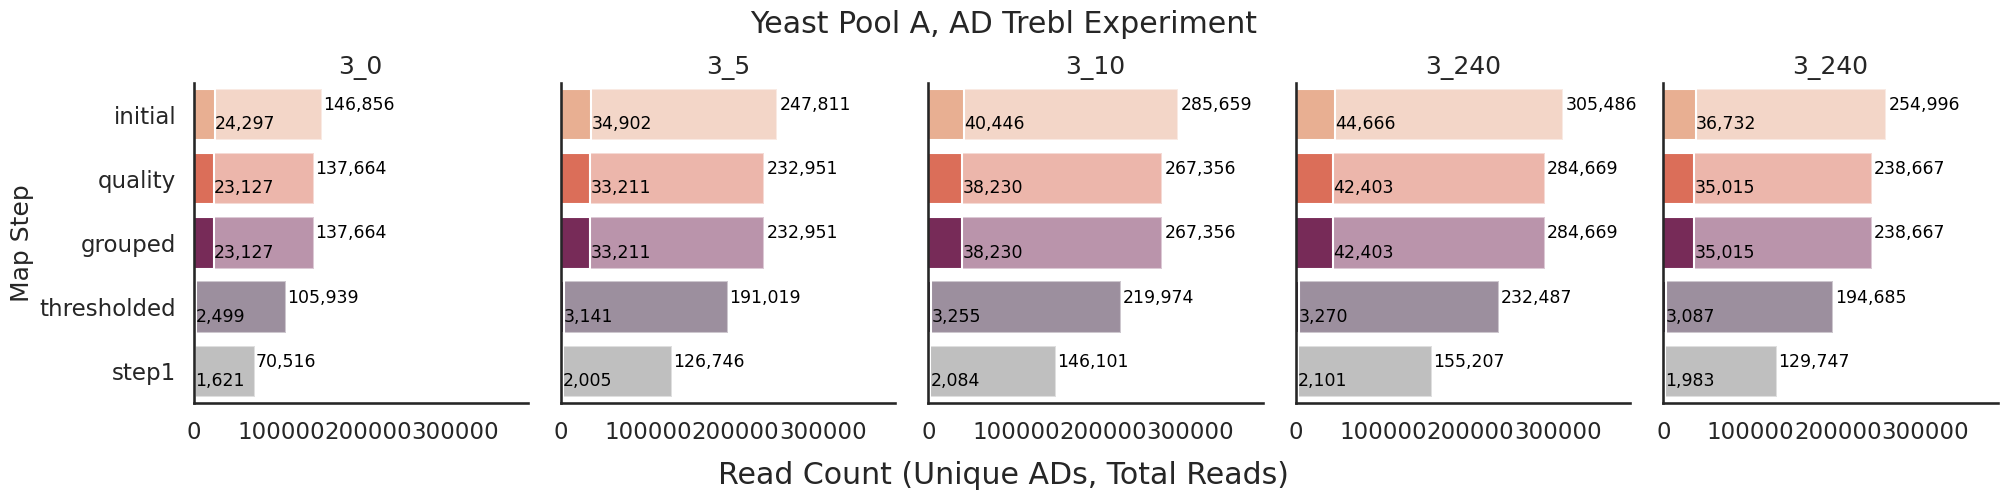

In [10]:
fig, axs = plt.subplots(1,5, sharey = True, sharex = True, figsize = (20,4))
axs = axs.flatten()

i = 0
for table in tqdm.tqdm(AD_prefixes_df["id"]):
    df = AD_loss_table_dict[table]
    df = df.drop(columns = "unique_count")
    df = df.rename(columns = {"unique_AD_count" : "unique_count"})
    
    plotting.plot_loss_helper(ax = axs[i], 
                                palette = 'rocket_r', 
                                text_offset =-0.15, 
                                show_background = True, 
                                default_map_order = ['initial', 'quality', 'designed', 'grouped', 'thresholded'], 
                                output_figures_path = "../../output/GCN4/figures/trebl_experiment_test",
                                table_prefix_with_descriptor = "test",
                                  df = df, 
                              hide_x = False)
    axs[i].set_title(str(AD_prefixes_df["rep"].iloc[i]) + "_" + str(AD_prefixes_df["time"].iloc[i]))
    i += 1
    

for ax in axs:
    ax.set_xlabel("")

    
plt.tight_layout(pad = 0.25)
fig.supxlabel("Read Count (Unique ADs, Total Reads)", y = -0.1)
plt.suptitle("Yeast Pool A, AD Trebl Experiment", y = 1.1)

100%|██████████| 5/5 [00:02<00:00,  2.42it/s]


Text(0.5, 1.1, 'Yeast Pool A, RT Trebl Experiment')

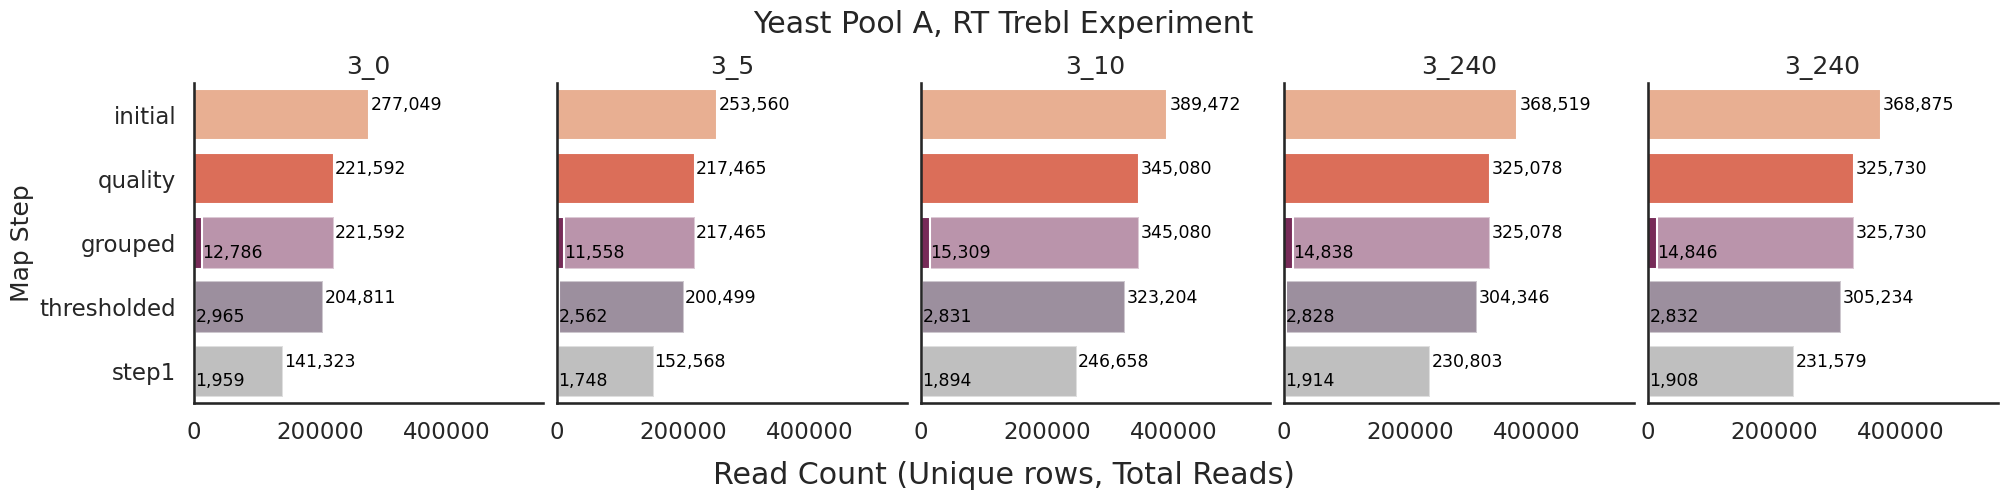

In [11]:
fig, axs = plt.subplots(1,5, sharey = True, sharex = True, figsize = (20,4))
axs = axs.flatten()

i = 0
for table in tqdm.tqdm(RT_prefixes_df["id"]):
    df = RT_loss_table_dict[table]

    plotting.plot_loss_helper(ax = axs[i], 
                                palette = 'rocket_r', 
                                text_offset =-0.15, 
                                show_background = True, 
                                default_map_order = ['initial', 'quality', 'designed', 'grouped', 'thresholded'], 
                                output_figures_path = "../../output/GCN4/figures/trebl_experiment_test",
                                table_prefix_with_descriptor = "test",
                                  df = df, 
                              hide_x = False)
    axs[i].set_title(str(RT_prefixes_df["rep"].iloc[i]) + "_" + str(RT_prefixes_df["time"].iloc[i]))
    i += 1
    

for ax in axs:
    ax.set_xlabel("")

    
plt.tight_layout(pad = 0.25)
fig.supxlabel("Read Count (Unique rows, Total Reads)", y = -0.1)
plt.suptitle("Yeast Pool A, RT Trebl Experiment", y = 1.1)

In [14]:
con.close()